# PCHN63101 Workshop 1: Statistical Modelling
In the accompanying lesson to this workshop we explored the general concept of a statistical model as a method of capturing the variance inherent within a dataset. We first saw how to define a descriptive measure of variance, before exploring how this notion of random variation can be formalised using concepts from the world of *probability*. Specifically, every value we measure is conceptualised as a random draw from a particular probability distribution. This distribution provides the *model* of our data-generating process and thus formalises the probabilistic behaviour of our measurements. The shape of every probability distribution is controlled by a number of *parameters* that, either directly or indirectly, inform the *expected value* and *variance* of the distribution. These can be thoughts of as the *most probable* value and the *width*. A statistical model is then concerned with assuming some population distribution for a given data set and then connecting the parameters of the distribution to the data via a *mean function* and a *variance* function.    

At present, some of these ideas may feel a bit abstract. However, over the coming weeks we will start to see them put into action and all this information should become more concrete. In this workshop, the focus will be on providing more intuition about all these topics. In part, this will involve demonstrating some of these ideas in code so that you can play around with them, get a feel for them and see how the output changes with different inputs and arguments. In general, playing with code is one of the *best* ways for gaining intuition about more abstract mathematical concepts.

## Sources of Variance
To begin, we will start with the basic concept of variance as the degree to which measured datapoints *differ* from each other. You should understand from the lesson one way in which we can capture this degree of variation, through the calculation of the sample variance. However, capturing variance is only ever a precursor to trying to *explain* variance. 

A core concept here is that data can vary for *two* reasons: systematic patterns, or random noise. Consider the code below and the resultant plots

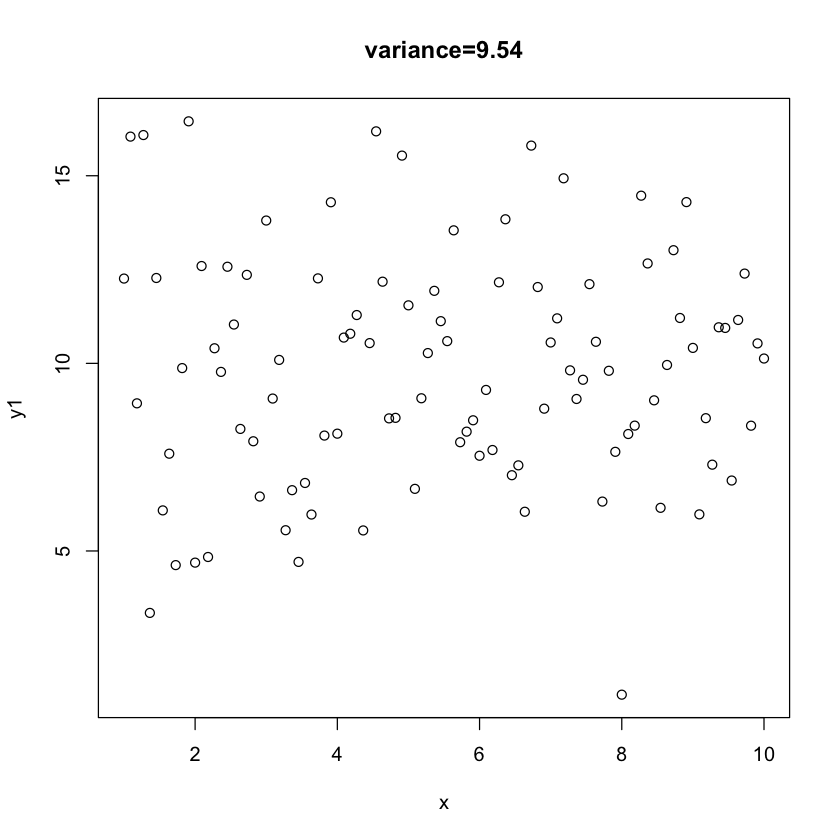

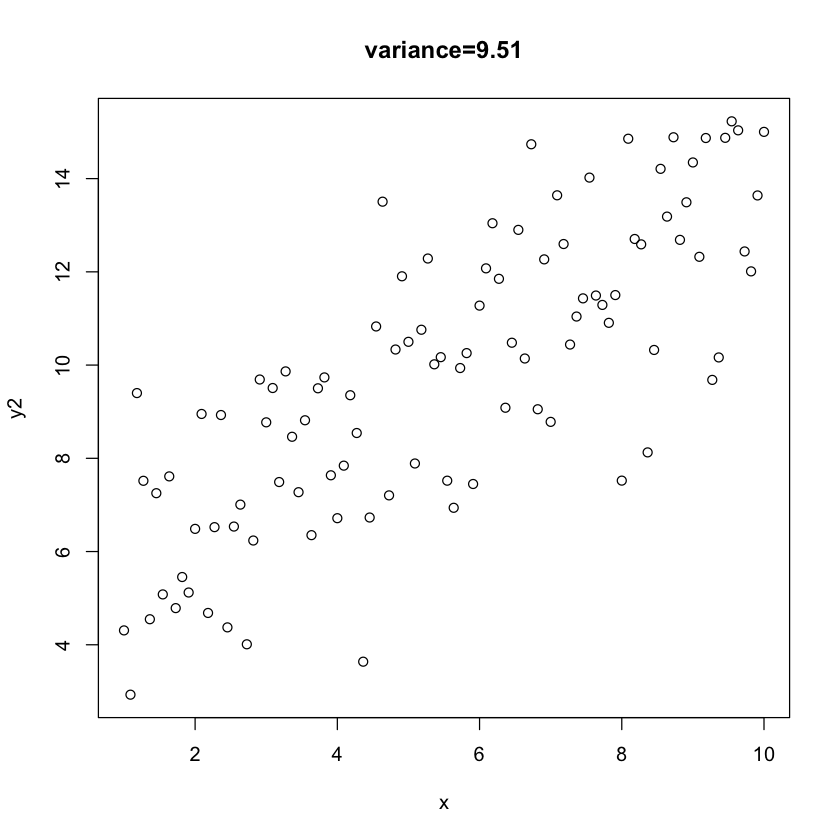

In [57]:
set.seed(666)
x <- seq(1, 10, length.out = 100)

y1 <- rnorm(100, 10, 3)                 # pure noise
y2 <- (5 + 0.9*x) + rnorm(100, 0, 1.68) # linear pattern + pure noise

var1 <- round(var(y1),2)
var2 <- round(var(y2),2)

plot(x, y1, main=paste0("variance=",var1)) 
plot(x, y2, main=paste0("variance=",var2))


The first plot contains random noise drawn from $\mathcal{N}\left(10,3\right)$, which is completely unrelated to the predictor variable $x$. The second plot contains a linear pattern between $x$ and $y$, with some random noise added. Both sets of data have nearly the same measurment of variance, yet the second one has a much clearer pattern between $x$ and $y$. This pattern represents the *predictable* element of the data, whereas the additional random noise represents the *unpredictable* element of the data. The job of any statistical model is to take the total amount of variance in the data and try to *split it* into the amount attributable to any systematic and predictable patterns, and the amount attributable to random noise.

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Imagine that the second plot above corresponds to an investigation into how mood, as measured using a questionnaire, improves based on the number of hours sleep someone gets the night before. If $y$ is mood and $x$ is hours of sleep, what does the systematic pattern in the data represent? What would you attribute this source of variance to? What about the noise? Why doesn't all the data perfectly adhere to the systematic pattern?
</div>

### Reducible and Irriducible Error
The idea of splitting variance into a *systematic* component and a *random noise* component relates to a key idea in statistics of *reducible* and *irriducible* error. For example, use the sleep and mood example, if we measured mood but had not captured hours of sleep, we would have no way of capturing the relationship we see above. The variance associated with this relationship would therefore get partitioned into the *random noise* component and the model error would be larger. However, if we include hours of sleep in our model, this relationship is captured, the *systematic* variance gets larger and the *random noise* gets smaller. We have therefore *reduced* the model error and so this is an example of *reducible* error. However, even with every measurement in the world we could never capture all the reasons why data varies, as there will always be some element that is just random noise. This is the *irreducible error*. We cannot get rid of it by making our model better and better because there will always be an element of real-world data that cannot be predicted.

## Random Variables as Variance Generators

### Creating Random Variables in `R`

### The Difficulties of the Sample Distribution
... As an example, the code below shows 9 examples of drawing data from a normal distribution and then plotting it. In this example, $n = 5$, which is a very small sample. Notice how difficult it is to assess the actual form of distribution from the sample, despite us knowing that each one was drawn from the same distribution.

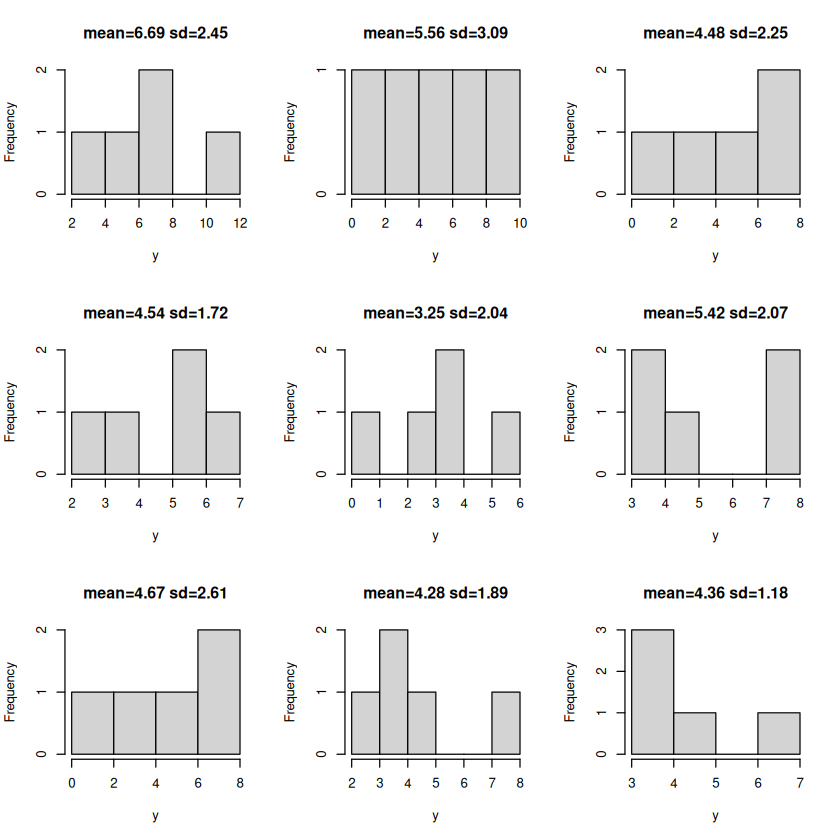

In [12]:
n <- 5
par(mfrow=c(3,3))
for (i in 1:9){
    y     <- rnorm(n, mean=5, sd=2)
    mu    <- mean(y)
    sigma <- sd(y)
    hist(y, main=paste0("mean=",round(mu,2)," sd=",round(sigma,2)))
}

par(mfrow=c(1,1)) # reset the display

<div class="alert alert-block alert-info"> 
<b>ACTIVITY</b> Alter the code above for different values of <code>n</code>. At what sample size do you think assuming normality based on the shape of the sample distribution is reasonable? What does this suggest about how reliable it is to use the basic shape of the sample distribution to determine the population distribution? Now consider how variable the estimates are for the <i>mean</i> and <i>standard deviation</i>, as written in the title of each histogram. Remember, the true values are a mean of 5 and a standard deviation of 2. How does this variability change with different values of <code>n</code> and what does this suggest about our ability to accurately estimate the population parameters from a sample?
</div>

### What if we get the distribution wrong?
... So, remembering the quote from George Box, we will *always* get the distribution "wrong" because the distribution is a *model* and no model is perfect. Our aim is then to choose something that is *as close as possible* such that the numbers produced by the model are useful.

### Scaling Random Variables

## Mean Functions and Variance Functions
... We can actually use R to define explicit functions for both the mean and variance. This can be helpful because it shows how the principles of the mathematical models translate into code. If you find code easier to understand, this can really help drive the point home.

In [17]:
mean.func <- function(){
    mu <- 5
    return(mu)
}

var.func <- function(){
    sigma2 <- 2
    return(sigma2)
}

Which would be equivalent to the model

$$
\begin{alignat*}{1}
    y_{i}           &\sim \mathcal{N}\left(\mu_{i},\sigma^{2}_{i}\right) \\
    \mu_{i}         &= 5 \\
    \sigma^{2}_{i}  &= 2 
\end{alignat*}
$$

... Now let us alter the mean and variance functions so that the value they return depends upon a predictor variable. This allows the mean and variance to *change* across measurements depending upon some other value.

As a final example, let us see how a simple regression model would be represented in this framework.

In [3]:
mean.func <- function(x){
    beta.0 <- 5
    beta.1 <- 2
    mu     <- beta.0 + beta.1*x
    return(mu)
}

var.func <- function(x){
    sigma2 <- 2
    return(sigma2)
}

<div class="alert alert-block alert-danger">
<b>IMPORTANT</b> The examples here all assume we know the values of the parameters. This is simply to illustrate how statistical models work. In reality, these values will be estimated from the data we have. So, when applied to real data, you can think of replacing the definition of the parameters values with question marks. This gives a <i>form</i> for the mean function and variance function, but these forms depend on values we do not know. The process of <i>fitting</i> or <i>estimating</i> a model is effectively using the data to <i>guess</i> what those values are. We can then replace the question marks with actual numbers.
</div>

## Simultating Data
Given the information above, we now have everything we need to *simulate* data. Although our aim is not usually simulation, the process of generating simulated data is useful for a number of reasons:

1. The simulation makes the assumed data-generating process very explicit
2. It allows us to see what sort of data our model would generates
3. It allows us to simulate data that perfectly matches the assumptions of our models
4. ...

Remember, when we have *real* data, our model is effectively suggesting a simplified version of the data-generating process. In other words, data simulated from the model and real data should be very close to each other. If they are not, then the model is inaccurate.